# Task 4 - Model Training

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [2]:
data = pd.read_csv('Data/train_data.csv')
data

,id,birth_date,age,gender,subscription_start,subscription_end,subscription_length,avg_invoice,total_invoices,sms,sms_roam,data,data_roam,phone_calls,calls_roam,churn
0,0,1986-10-30,32,F,2010-08-18,2018-01-01,2693,49.805556,1793,2.506069,0.211018,127.529563,0.634961,315.273859,0.096266,False
1,1,1967-03-22,51,M,1997-07-05,2018-01-01,7485,43.694444,1573,2.523311,0.186489,128.289575,0.665380,305.975507,0.086149,False
2,2,1965-12-25,53,M,2003-05-23,2018-01-01,5337,49.805556,1793,2.542373,0.209372,127.429825,0.677945,314.724333,0.110752,False
3,3,1988-06-17,30,F,2013-09-14,2018-01-01,1570,44.083333,1587,2.516370,0.210477,130.208955,0.686567,298.559564,0.092282,False
4,4,1964-12-18,54,M,2004-01-28,2018-01-01,5087,45.500000,1638,2.575605,0.201613,132.553665,0.680628,301.945813,0.094417,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,995,1962-08-11,56,M,2003-05-31,2018-01-01,5329,43.194444,1555,2.568411,0.219467,126.781638,0.668734,294.975382,0.079796,False
996,996,1987-12-10,31,F,2007-11-18,2018-01-01,3697,43.777778,1576,2.577132,0.230490,146.413669,0.685851,304.665543,0.082561,False
997,997,1989-10-24,29,F,2007-10-24,2017-12-13,3703,41.388889,1490,2.504845,0.206395,132.770574,0.670823,206.115166,0.105434,True
998,998,1980-04-04,38,F,2013-10-03,2018-01-01,1551,48.638889,1751,2.707823,0.200754,143.475309,0.656790,296.846416,0.103242,False


In [3]:
# Replace M with 1 and F with 0
data['gender'] = data['gender'].map({'M': 1, 'F': 0})
data.fillna(0, inplace=True)
data.head()

,id,birth_date,age,gender,subscription_start,subscription_end,subscription_length,avg_invoice,total_invoices,sms,sms_roam,data,data_roam,phone_calls,calls_roam,churn
0,0,1986-10-30,32,0,2010-08-18,2018-01-01,2693,49.805556,1793,2.506069,0.211018,127.529563,0.634961,315.273859,0.096266,False
1,1,1967-03-22,51,1,1997-07-05,2018-01-01,7485,43.694444,1573,2.523311,0.186489,128.289575,0.665380,305.975507,0.086149,False
2,2,1965-12-25,53,1,2003-05-23,2018-01-01,5337,49.805556,1793,2.542373,0.209372,127.429825,0.677945,314.724333,0.110752,False
3,3,1988-06-17,30,0,2013-09-14,2018-01-01,1570,44.083333,1587,2.516370,0.210477,130.208955,0.686567,298.559564,0.092282,False
4,4,1964-12-18,54,1,2004-01-28,2018-01-01,5087,45.500000,1638,2.575605,0.201613,132.553665,0.680628,301.945813,0.094417,False


In [4]:
features = ['age', 'gender', 'subscription_length', 'avg_invoice', 'total_invoices', 'sms', 'sms_roam', 'data', 'data_roam', 'phone_calls', 'calls_roam', 'churn']
cleaned_df = data[features].copy()

In [5]:
train_df, test_df = train_test_split(cleaned_df, test_size=0.2)
train_df, val_df = train_test_split(train_df, test_size=0.2)

train_labels = np.array(train_df.pop('churn'))
val_labels = np.array(val_df.pop('churn'))
test_labels = np.array(test_df.pop('churn'))

train_features = np.array(train_df)
val_features = np.array(val_df)
test_features = np.array(test_df)

In [6]:
scaler = StandardScaler()
train_features = scaler.fit_transform(train_features)

val_features = scaler.transform(val_features)
test_features = scaler.transform(test_features)

print('Training labels shape:', train_labels.shape)
print('Validation labels shape:', val_labels.shape)
print('Test labels shape:', test_labels.shape)

print('Training features shape:', train_features.shape)
print('Validation features shape:', val_features.shape)
print('Test features shape:', test_features.shape)

Training labels shape: (640,)
Validation labels shape: (160,)
Test labels shape: (200,)
Training features shape: (640, 11)
Validation features shape: (160, 11)
Test features shape: (200, 11)


# Models

## Support Vector Machines

In [7]:
from sklearn.svm import SVC
clf = SVC().fit(train_features, train_labels)
prediction = clf.predict(test_features)

### Scores

In [8]:
# Calculate score on test data
clf.score(test_features, test_labels) * 100

97.5

In [9]:
# Calculate score on validation data
clf.score(val_features, val_labels) * 100

98.125

### Reports and Graphs

In [10]:
from sklearn.metrics import classification_report
print(classification_report(test_labels, prediction))

              precision    recall  f1-score   support

       False       0.99      0.98      0.99       175
        True       0.86      0.96      0.91        25

    accuracy                           0.97       200
   macro avg       0.93      0.97      0.95       200
weighted avg       0.98      0.97      0.98       200



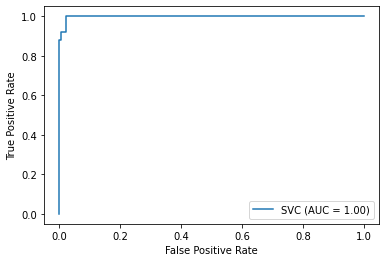

In [11]:
from sklearn.metrics import plot_roc_curve
plot_roc_curve(clf, test_features, test_labels)

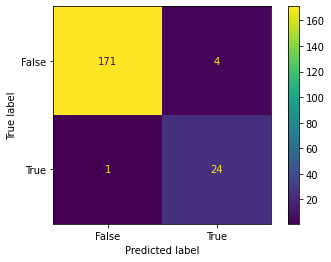

In [12]:
from sklearn.metrics import plot_confusion_matrix
plot_confusion_matrix(clf, test_features, test_labels)

#### Confusion Matrix for validation data

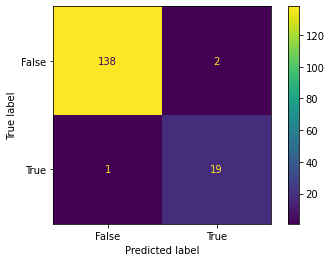

In [13]:
plot_confusion_matrix(clf, val_features, val_labels)

## Decision Trees

In [14]:
from sklearn.tree import DecisionTreeClassifier
clf = DecisionTreeClassifier()
clf.fit(train_features, train_labels)
prediction = clf.predict(test_features)

### Scores

In [15]:
clf.score(test_features, test_labels) * 100

96.5

In [16]:
clf.score(val_features, val_labels) * 100

96.25

### Reports and Graphs

In [17]:
print(classification_report(test_labels, prediction))

              precision    recall  f1-score   support

       False       0.99      0.97      0.98       175
        True       0.82      0.92      0.87        25

    accuracy                           0.96       200
   macro avg       0.90      0.95      0.92       200
weighted avg       0.97      0.96      0.97       200



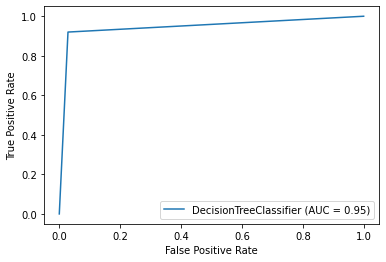

In [18]:
plot_roc_curve(clf, test_features, test_labels)

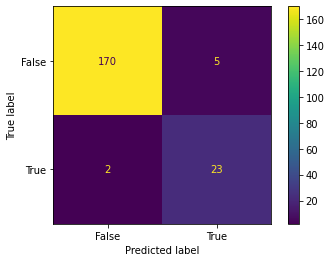

In [19]:
plot_confusion_matrix(clf, test_features, test_labels)

#### Confusion Matrix for validation data

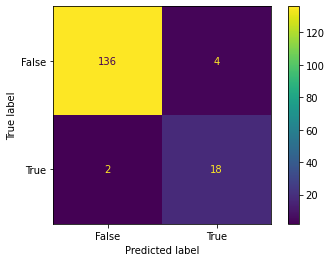

In [20]:
plot_confusion_matrix(clf, val_features, val_labels)

## K-Nearest Neighbours

In [21]:
from sklearn.neighbors import KNeighborsClassifier
clf = KNeighborsClassifier()
clf.fit(train_features, train_labels)
prediction = clf.predict(test_features)

### Scores

In [22]:
clf.score(test_features, test_labels) * 100

97.5

In [23]:
clf.score(val_features, val_labels) * 100

96.25

### Reports and Graphs

In [24]:
print(classification_report(test_labels, prediction))

              precision    recall  f1-score   support

       False       0.98      0.99      0.99       175
        True       0.95      0.84      0.89        25

    accuracy                           0.97       200
   macro avg       0.97      0.92      0.94       200
weighted avg       0.97      0.97      0.97       200



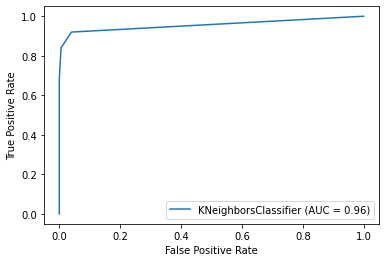

In [25]:
plot_roc_curve(clf, test_features, test_labels)

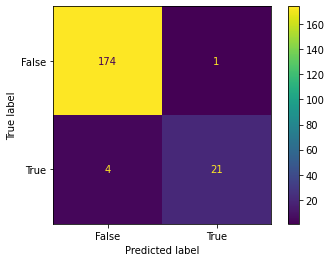

In [26]:
plot_confusion_matrix(clf, test_features, test_labels)

#### Confusion Matrix for validation data

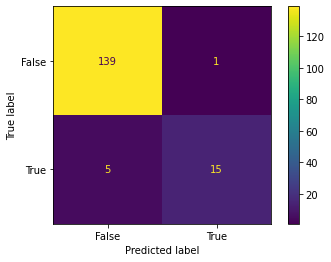

In [27]:
plot_confusion_matrix(clf, val_features, val_labels)

## Multiple model evaluation

In [28]:
def evalute_models(models: dict,
                   train_features: np.array,
                   train_labels: np.array,
                   test_features: np.array,
                   test_labels: np.array,
                   val_features: np.array,
                   val_labels: np.array) -> dict:
    '''
    Input parameters
    ----------------
    models         a dictionary containing different classifiers
    train_features contains features for training
    train_labels   contains labels for training
    test_features  contains features for testing
    test_labels    contains labels for comparing prediction results
    test_features  contains features for validation
    test_labels    contains labels for comparing prediction results
    
    Return
    ----------------
    scores         a dictionary containing reports, scores and graphs
    '''
    
    scores = {}
    for k, v in models.items():
        clf = v.fit(train_features, train_labels)
        prediction = clf.predict(test_features)
        test_score = clf.score(test_features, test_labels) * 100
        val_score = clf.score(val_features, val_labels) * 100
        report = classification_report(test_labels, prediction)
        roc_auc = plot_roc_curve(clf, test_features, test_labels)
        test_cm = plot_confusion_matrix(clf, test_features, test_labels)
        val_cm = plot_confusion_matrix(clf, val_features, val_labels)
        score = [test_score, val_score, report, roc_auc, test_cm, val_cm]
        scores[k] = score
    return scores

/Users/hristijanpetreski/Documents/Internship/jupyter/lib/python3.8/site-packages/sklearn/metrics/_plot/confusion_matrix.py:81: RuntimeWarning: More than 20 figures have been opened. Figures created through the pyplot interface (`matplotlib.pyplot.figure`) are retained until explicitly closed and may consume too much memory. (To control this warning, see the rcParam `figure.max_open_warning`).
  fig, ax = plt.subplots()


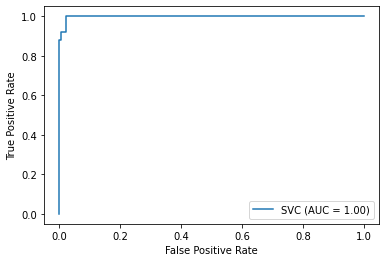

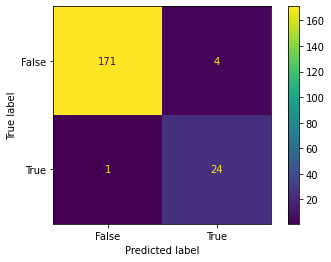

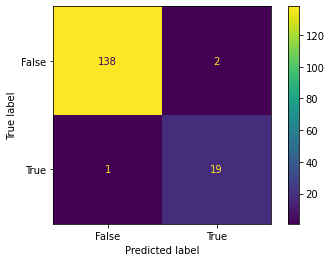

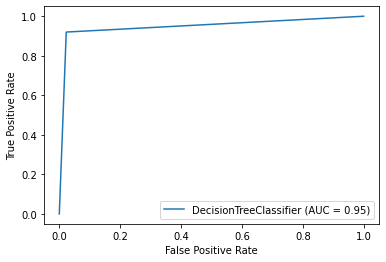

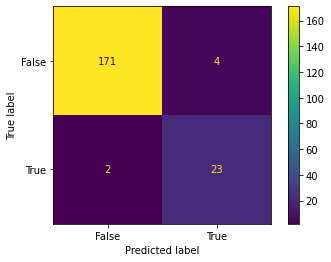

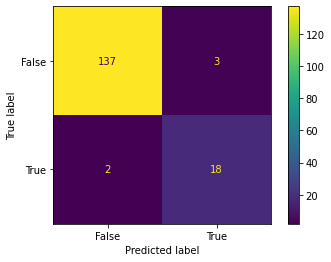

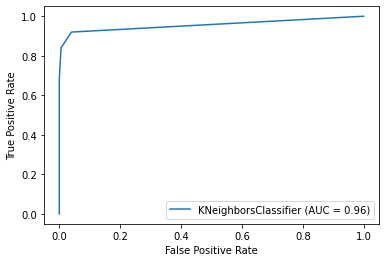

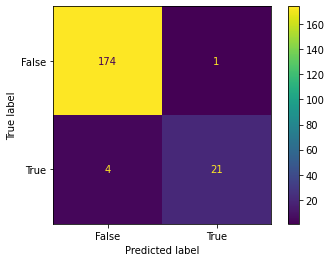

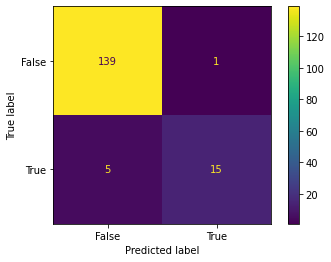

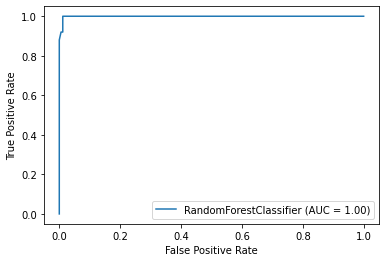

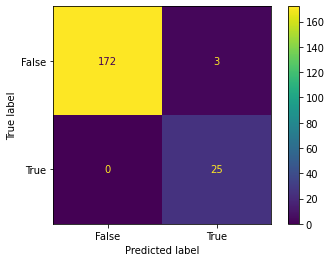

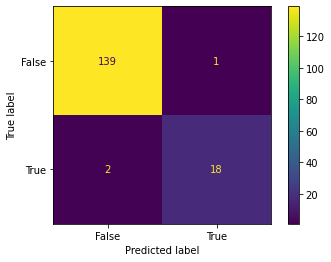

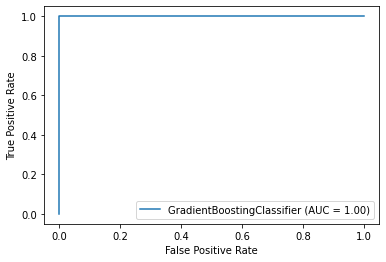

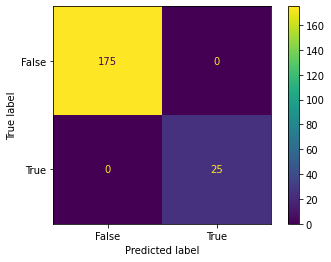

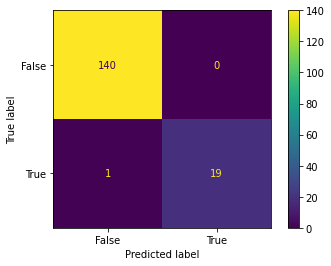

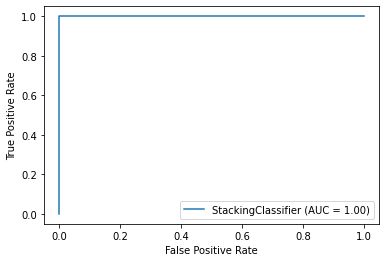

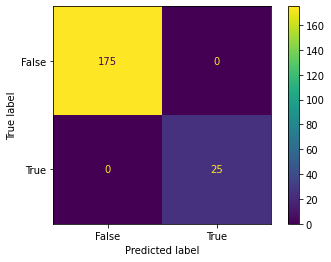

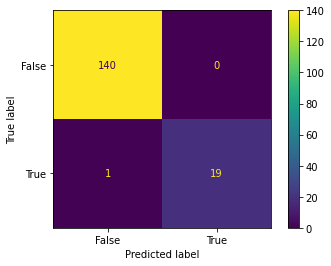

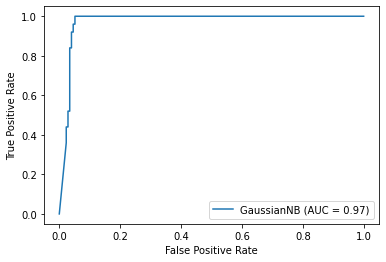

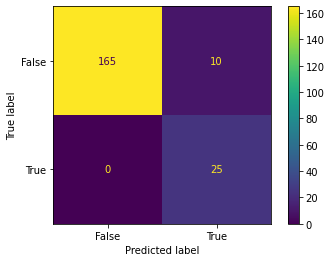

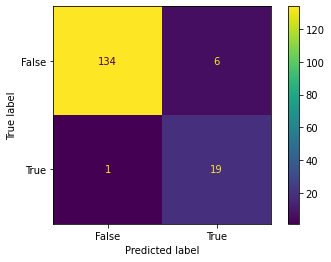

In [29]:
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier, StackingClassifier

models = {
    'SVC': SVC(),
    'DT': DecisionTreeClassifier(),
    'KNN': KNeighborsClassifier(),
    'RF': RandomForestClassifier(),
    'GB': GradientBoostingClassifier(),
    'SC': StackingClassifier(estimators=[
        ('rf', RandomForestClassifier()),
        ('gb', GradientBoostingClassifier())
    ]),
    'GNB': GaussianNB()
}
scores = evalute_models(models, train_features, train_labels, test_features, test_labels, val_features, val_labels)

In [30]:
for k, v in scores.items():
    print(k)
    print(f'Test Data Score = {v[0]}; Valuation Data Score = {v[1]}')
    print(v[2])
    print('------------------------------------------------------\n\n')

SVC
Test Data Score = 97.5; Valuation Data Score = 98.125
              precision    recall  f1-score   support

       False       0.99      0.98      0.99       175
        True       0.86      0.96      0.91        25

    accuracy                           0.97       200
   macro avg       0.93      0.97      0.95       200
weighted avg       0.98      0.97      0.98       200

------------------------------------------------------


DT
Test Data Score = 97.0; Valuation Data Score = 96.875
              precision    recall  f1-score   support

       False       0.99      0.98      0.98       175
        True       0.85      0.92      0.88        25

    accuracy                           0.97       200
   macro avg       0.92      0.95      0.93       200
weighted avg       0.97      0.97      0.97       200

------------------------------------------------------


KNN
Test Data Score = 97.5; Valuation Data Score = 96.25
              precision    recall  f1-score   support

     